# Magnetic fields

Here we illustrate how to define and work with magnetic fields, using the ``atomsmltr.environment.fields.magnetic`` subpackage

## magnetic field offset

In [4]:
from atomsmltr.environment import MagneticOffset

# offset pointing along y, with amplitude of 0.1T
mag_offset = MagneticOffset(offset=(0,0.1,0), tag="offset")

# print infos
mag_offset.print_info()

# check value at one position
display(mag_offset.value((1,2,3)))

─────────────────────────
| Magnetic field offset |
─────────────────────────
. Parameters :
  ├── type : offset (constant field)
  ├── tag : offset
  ├── value (T) : [0.  0.1 0. ]
  └── norm (T) : 0.1




array([0. , 0.1, 0. ])

## magnetic field gradient

───────────────────────────
| Magnetic field gradient |
───────────────────────────
. Parameters :
  ├── type : perfect gradient
  ├── tag : gradient
  ├── slope (T/m) : 0.5
  ├── gradient direction : [0. 0. 1.]
  ├── field direction : [1. 0. 0.]
  ├── origin (m) : [0 0 0]
  └── offset (T) :   0




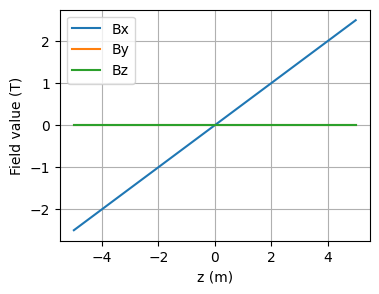

In [ ]:
from atomsmltr.environment import MagneticGradient
import numpy as np
import matplotlib.pyplot as plt

# offset pointing along x, with a slope of 0.5T/m along z
mag_gradient = MagneticGradient(
    origin=(0, 0, 0),
    slope=0.5,
    gradient_direction=(0, 0, 1),
    field_direction=(1, 0, 0),
    offset=0,
    tag="gradient",
)

# print infos
mag_gradient.print_info()

# compute values along z
zlist = np.linspace(-5,5,1000)
r = np.array([[0,0,z] for z in zlist])
B = mag_gradient.value(r)

# get components
Bx, By, Bz = B.T

# plot
plt.figure(figsize=(4,3))
plt.plot(zlist, Bx, label="Bx")
plt.plot(zlist, By, label="By")
plt.plot(zlist, Bz, label="Bz")
plt.grid()
plt.ylabel("Field value (T)")
plt.xlabel("z (m)")
plt.legend()
plt.show()

we can also use some built-in plot functions

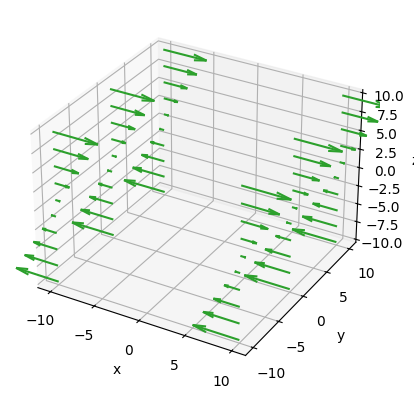

<Axes3D: xlabel='x', ylabel='y', zlabel='z'>

In [26]:
limits = (-10, 10, -10, 10, -10, 10)
Npoints = (2, 3, 10)
mag_gradient.plot3D(
    limits=limits,
    Npoints=Npoints,
    show=True,
    color="C2",
    normalize=True,
    scale=5,
)

## magnetic field quadrupole

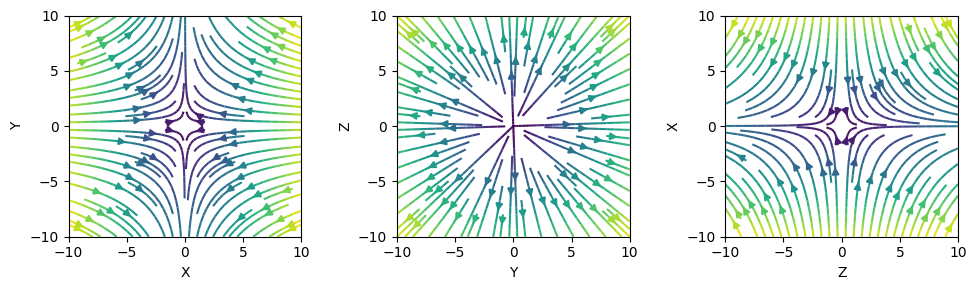

In [37]:
from atomsmltr.environment import MagneticQuadrupoleX

quadX = MagneticQuadrupoleX(origin=(0, 0, 0), slope=0.5)

Npoints = 50
limits = (-10, 10, -10, 10)
fig, axes = plt.subplots(1, 3, figsize=(10, 3), tight_layout=True)
quadX.plot2D(plane="XY", limits=limits, Npoints=Npoints, ax=axes[0])
quadX.plot2D(plane="YZ", limits=limits, Npoints=Npoints, ax=axes[1])
quadX.plot2D(plane="ZX", limits=limits, Npoints=Npoints, ax=axes[2])
plt.show()